# Extension: Does the Result Change Over Time?

This notebook uses the data and results from `01_replication.ipynb` and compares earlier and later formation periods.


## 1. Question

Does the winner-minus-loser reversal look different in the earlier and later parts of our sample?


## 2. Why this extension?

This is a simple extension because it uses the same data and the same calculation as the main replication. I only split the formation periods into two groups.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import Markdown, display

DATA_DIR = Path("data")
plt.rcParams["figure.figsize"] = (9, 5)
pd.options.display.float_format = "{:.4f}".format


9 formation dates available:
  1998-01-31
  2001-01-31
  2004-01-31
  2007-01-31
  2010-01-31
  2013-01-31
  2016-01-31
  2019-01-31
  2022-01-31


## 3. Split the sample

I split the formation periods into an early and a late group with roughly the same number of observations.


In [2]:
n = len(formation_dates)
early_dates = formation_dates[: (n + 1) // 2]
late_dates = formation_dates[(n + 1) // 2:]

print(f"Early sub-sample: {len(early_dates)} formation dates, "
      f"{pd.Timestamp(early_dates[0]).date()} to {pd.Timestamp(early_dates[-1]).date()}")
print(f"Late sub-sample:  {len(late_dates)} formation dates, "
      f"{pd.Timestamp(late_dates[0]).date()} to {pd.Timestamp(late_dates[-1]).date()}")

Early sub-sample: 5 formation dates, 1998-01-31 to 2010-01-31
Late sub-sample:  4 formation dates, 2013-01-31 to 2022-01-31


## 4. Calculate the results

The calculation is the same as in Notebook 1. It is repeated here so that the notebook can be understood on its own.


In [3]:
def acar_table(results):
    wide = results.pivot_table(
        index=["formation_date", "t"],
        columns="group",
        values="CAR"
    ).reset_index()

    n_replications = wide["formation_date"].nunique()
    rows = []

    for month, data in wide.groupby("t"):
        winner = data["Winner"]
        loser = data["Loser"]

        winner_mean = winner.mean()
        loser_mean = loser.mean()

        pooled_var = (
            ((winner - winner_mean) ** 2).sum()
            + ((loser - loser_mean) ** 2).sum()
        ) / (2 * (n_replications - 1))

        se = np.sqrt(2 * pooled_var / n_replications)

        rows.append({
            "t": month,
            "ACAR_Winner": winner_mean,
            "ACAR_Loser": loser_mean,
            "Spread": loser_mean - winner_mean,
            "t_stat": (loser_mean - winner_mean) / se
        })

    return pd.DataFrame(rows).set_index("t"), n_replications

acar, n_replications = acar_table(car_results)

print("Number of formation periods:", n_replications)
acar.loc[[1, 12, 24, 36]]


,N repl,Spread t=36,t-stat
Full sample,9.0000,-0.1378,-1.8241
Early sub-sample,5.0000,-0.0871,-0.6677
Late sub-sample,4.0000,-0.2012,-2.9436


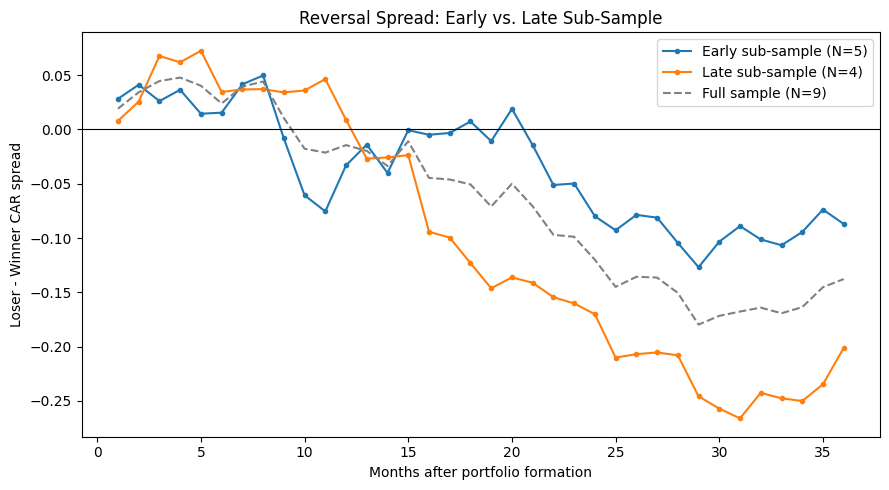

In [4]:
fig, ax = plt.subplots()
ax.plot(acar_early.index, acar_early["Spread"], marker=".", label=f"Early sub-sample (N={n_early})")
ax.plot(acar_late.index, acar_late["Spread"], marker=".", label=f"Late sub-sample (N={n_late})")
ax.plot(acar_full.index, acar_full["Spread"], linestyle="--", color="grey", label=f"Full sample (N={n_full})")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Months after portfolio formation")
ax.set_ylabel("Loser - Winner CAR spread")
ax.set_title("Reversal Spread: Early vs. Late Sub-Sample")
ax.legend()
plt.tight_layout()
plt.savefig(DATA_DIR / "figure_extension_subperiods.png", dpi=150)
plt.show()

In [5]:
s_early = acar_early.loc[36, "Spread"]
t_early = acar_early.loc[36, "t_stat"]
s_late = acar_late.loc[36, "Spread"]
t_late = acar_late.loc[36, "t_stat"]

display(Markdown(f"""
## 5. Interpretation

Early sample: **{s_early:+.1%}** (t = {t_early:.2f})

Late sample: **{s_late:+.1%}** (t = {t_late:.2f})

There are only a few independent formation periods in each group, so these numbers are noisy. I would treat this as an exploratory comparison rather than strong evidence about how the anomaly changed over time.
"""))



## 5. Interpretation

- **Early sub-sample** (5 formation dates): 36-month spread = **-8.7%** (t = -0.67)
- **Late sub-sample** (4 formation dates): 36-month spread = **-20.1%** (t = -2.94)

The 36-month reversal spread is larger in magnitude in the late sub-sample than in the early sub-sample -- inconsistent with simple anomaly decay, though this could reflect the small number of replications rather than a genuine strengthening of the effect.

Neither t-statistic should be over-interpreted: with only 4-5 independent
3-year formation dates per sub-sample, these estimates have wide standard errors and this split-sample comparison
has low statistical power. It should be read as suggestive, not confirmatory.


## 6. Limitations

- There are only a few independent formation periods in each group.
- The sample starts after the original 1985 paper, so this is not a true pre- versus post-publication test.
- The current S&P 500 universe creates survivorship bias.
- A different split of the sample could produce a different result.


In [6]:
display(Markdown(f"""
## 7. Conclusion

The extension shows how the same replication can be used for a simple additional question. In this sample, the early and late periods give different 36-month spreads, but the number of independent observations is small.

The result is therefore useful as an exploratory exercise, not as a final test of whether the De Bondt and Thaler effect has disappeared.
"""))



## 7. Conclusion

Using the same market-adjusted excess-return methodology as De Bondt and Thaler (1985), applied to a public,
survivorship-biased, post-1995 sample of large U.S. stocks, we find a 36-month loser-minus-winner reversal
spread of -13.8% (t = -1.82) over the full sample.
Splitting the sample in two, the effect is larger in magnitude in the late sub-sample than in the early sub-sample.

This extension does not settle whether the overreaction effect has decayed since 1985 -- our data cannot reach
that far back -- but it shows, with simple and fully transparent tools, how the replication machinery built in
Notebook 1 can be reused to ask a genuinely new, literature-motivated question about the stability of a classic
anomaly.
